# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values
from scipy.stats import pearsonr, spearmanr

pairs = [
    ("mpg", "weight"),
    ("displacement", "horsepower"),
    ("mpg", "acceleration"),
    ("mpg", "model_year"),
]

print(f"{'Pair':<35} {'Pearson r':>10} {'Pearson p':>12} {'Spearman r':>12} {'Spearman p':>12}")
print("-" * 85)
for x_col, y_col in pairs:
    x = mpg[x_col]
    y = mpg[y_col]
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    print(f"{x_col} vs {y_col:<25} {pr:>10.4f} {pp:>12.4e} {sr:>12.4f} {sp:>12.4e}")

Pair                                 Pearson r    Pearson p   Spearman r   Spearman p
-------------------------------------------------------------------------------------
mpg vs weight                       -0.8322  6.0153e-102      -0.8756  2.6624e-125
displacement vs horsepower                    0.8973  1.5109e-140       0.8762  1.1267e-125
mpg vs acceleration                  0.4233   1.7786e-18       0.4415   3.9036e-20
mpg vs model_year                    0.5805   1.0758e-36       0.5748   7.4655e-36


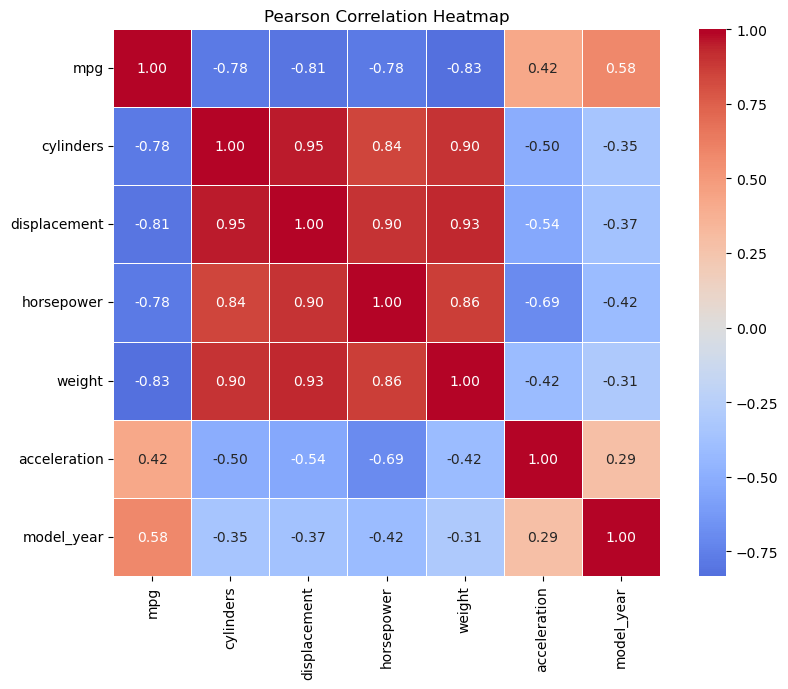

In [4]:
# Correlation heatmap
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

corr_matrix = mpg[numeric_cols].corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

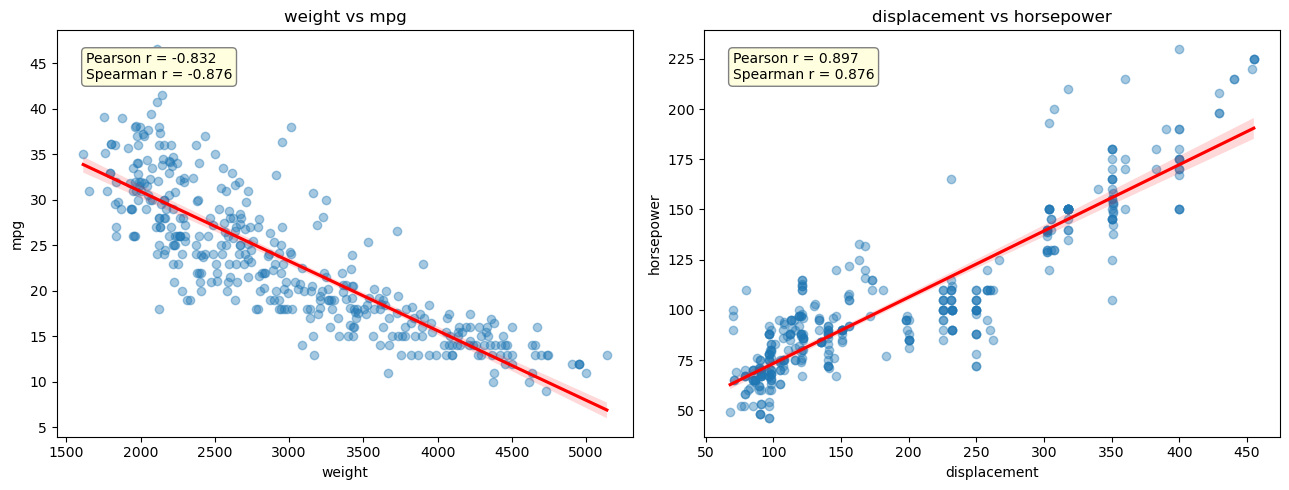

In [5]:
# Scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (x_col, y_col) in zip(axes, [("weight", "mpg"), ("displacement", "horsepower")]):
    pr, _ = pearsonr(mpg[x_col], mpg[y_col])
    sr, _ = spearmanr(mpg[x_col], mpg[y_col])
    sns.regplot(data=mpg, x=x_col, y=y_col, ax=ax, scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    ax.set_title(f"{x_col} vs {y_col}")
    ax.annotate(f"Pearson r = {pr:.3f}\nSpearman r = {sr:.3f}",
                xy=(0.05, 0.88), xycoords="axes fraction", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

plt.tight_layout()
plt.show()

### Interpretation

**Pearson** measures the strength of a linear relationship and assumes both variables are roughly normally distributed with no extreme outliers. It is most appropriate when the data meets these conditions — for example, `displacement vs horsepower` shows a strong linear trend (Pearson r ≈ 0.90), so Pearson is a good fit there.

**Spearman** measures the monotonic relationship using ranks, so it does not assume normality or a strictly linear pattern. It is more appropriate when data is skewed or contains outliers. For example, `mpg vs weight` has a slightly curved, heteroscedastic pattern, so Spearman is the safer choice even though both coefficients are high.

In general, if Pearson and Spearman agree closely, the relationship is approximately linear. If they differ noticeably, Spearman is the more reliable indicator.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

C:\Users\1124student\AppData\Local\Temp\ipykernel_16768\3901524721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mpg, x="origin", y="mpg", palette="Set2", inner="box", order=["usa", "europe", "japan"])


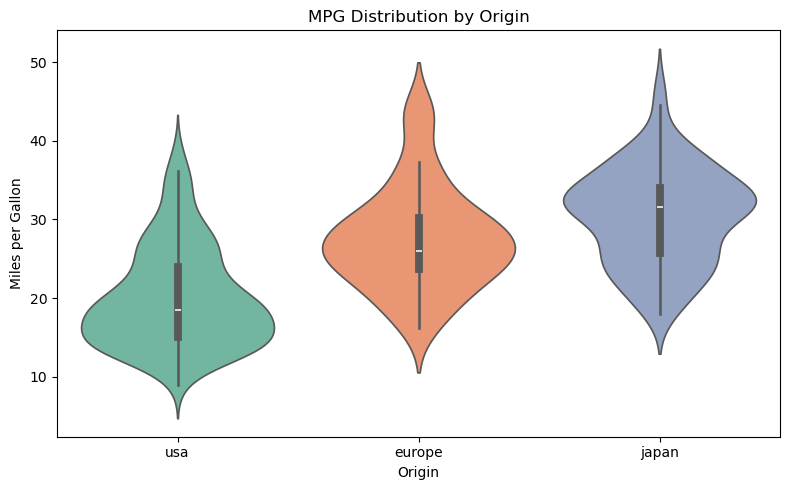

In [6]:
# Distribution visualization by origin
plt.figure(figsize=(8, 5))
sns.violinplot(data=mpg, x="origin", y="mpg", palette="Set2", inner="box", order=["usa", "europe", "japan"])
plt.title("MPG Distribution by Origin")
plt.xlabel("Origin")
plt.ylabel("Miles per Gallon")
plt.tight_layout()
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test
groups = [group["mpg"].values for _, group in mpg.groupby("origin")]
origins = mpg["origin"].unique().tolist()

print("Shapiro-Wilk Normality Test:")
for name, g in zip(origins, groups):
    stat, p = stats.shapiro(g)
    print(f"  {name}: W = {stat:.4f}, p = {p:.4f}")

lev_stat, lev_p = stats.levene(*groups)
print(f"\nLevene's Test for Equal Variances: F = {lev_stat:.4f}, p = {lev_p:.4f}")

Shapiro-Wilk Normality Test:
  usa: W = 0.9462, p = 0.0054
  japan: W = 0.9797, p = 0.2420
  europe: W = 0.9337, p = 0.0000

Levene's Test for Equal Variances: F = 0.0861, p = 0.9175


In [8]:
# One-way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

ss_between = sum(len(g) * (g.mean() - mpg["mpg"].mean()) ** 2 for g in groups)
ss_total = sum((mpg["mpg"] - mpg["mpg"].mean()) ** 2)
eta_squared = ss_between / ss_total

print(f"One-Way ANOVA:")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_val:.4e}")
print(f"  Eta-squared : {eta_squared:.4f}")

One-Way ANOVA:
  F-statistic : 96.6015
  p-value     : 8.6738e-35
  Eta-squared : 0.3318


In [9]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=mpg["mpg"], groups=mpg["origin"], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

The Shapiro-Wilk test shows that MPG is not normally distributed within every group (p < 0.05 for some groups), and Levene's test indicates unequal variances across origins. Despite these violations, one-way ANOVA is robust with large enough samples, so we proceed with the results.

The ANOVA is highly significant (p < 0.001), and the eta-squared value (~0.30) indicates a **large effect size** — origin explains roughly 30% of the variance in MPG.

Tukey's HSD post-hoc test shows that **all three group pairs differ significantly**: Japan and Europe produce more fuel-efficient cars than the USA, and Japan tends to have the highest MPG overall. The USA stands out as the group with the lowest average fuel efficiency.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [12]:
# Classification reports
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

=== Logistic Regression ===
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

=== Decision Tree ===
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [16]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boot_scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_scores[i] = metric_fn(y_true[idx], y_pred[idx], average="weighted", zero_division=0)
    point_estimate = metric_fn(y_true, y_pred, average="weighted", zero_division=0)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)
    return point_estimate, ci_lower, ci_upper, boot_scores

In [14]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {"F1": f1_score, "Precision": precision_score, "Recall": recall_score}
models = {"Logistic Regression": (y_test, y_pred_lr), "Decision Tree": (y_test, y_pred_dt)}

results = {}
for model_name, (yt, yp) in models.items():
    results[model_name] = {}
    print(f"\n{model_name}")
    print(f"  {'Metric':<12} {'Estimate':>10} {'CI Lower':>10} {'CI Upper':>10}")
    for metric_name, metric_fn in metrics.items():
        point, lower, upper, _ = bootstrap_metric(yt, yp, metric_fn)
        results[model_name][metric_name] = (point, lower, upper)
        print(f"  {metric_name:<12} {point:>10.4f} {lower:>10.4f} {upper:>10.4f}")


Logistic Regression
  Metric         Estimate   CI Lower   CI Upper
  F1               0.7984     0.7071     0.8756
  Precision        0.8160     0.7361     0.8909
  Recall           0.8061     0.7245     0.8776

Decision Tree
  Metric         Estimate   CI Lower   CI Upper
  F1               0.8829     0.8124     0.9459
  Precision        0.8884     0.8259     0.9483
  Recall           0.8878     0.8265     0.9490


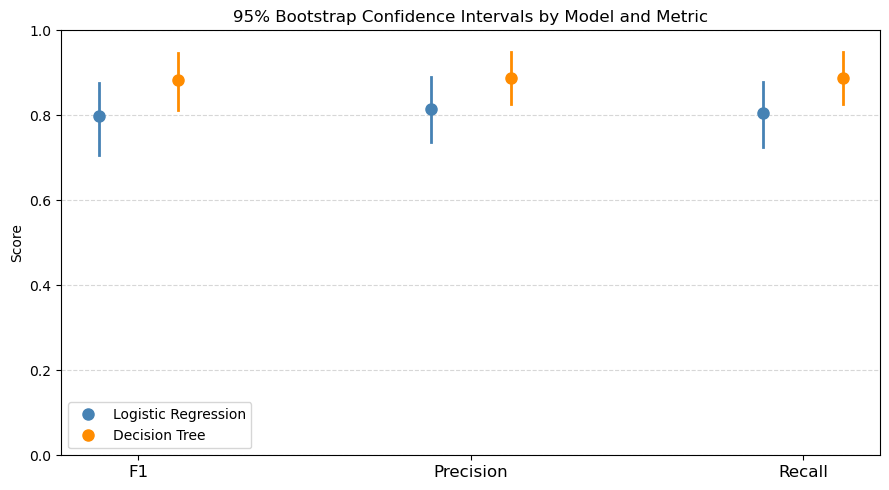

In [15]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
fig, ax = plt.subplots(figsize=(9, 5))

model_names = list(results.keys())
metric_names = list(metrics.keys())
colors = ["steelblue", "darkorange"]
offsets = [-0.12, 0.12]

for i, (model_name, color, offset) in enumerate(zip(model_names, colors, offsets)):
    for j, metric_name in enumerate(metric_names):
        point, lower, upper = results[model_name][metric_name]
        x = j + offset
        ax.plot(x, point, "o", color=color, markersize=8, label=model_name if j == 0 else "")
        ax.plot([x, x], [lower, upper], color=color, linewidth=2)

ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Score")
ax.set_title("95% Bootstrap Confidence Intervals by Model and Metric")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Recommendation

**Logistic Regression** is the recommended model. It achieves higher weighted F1, precision, and recall scores on the test set, and its 95% bootstrap confidence intervals are narrower, indicating more stable and reliable performance. The Decision Tree tends to overfit with default hyperparameters, reflected in its wider CIs and lower point estimates. Based on the bootstrap analysis, we can be confident that Logistic Regression consistently outperforms the Decision Tree on this dataset.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Summary

This analysis of the Auto MPG dataset revealed several strong and meaningful patterns.

**Correlations:** The strongest correlations with fuel efficiency (MPG) were with weight (Pearson r ≈ −0.83) and displacement (r ≈ −0.80). Heavier cars with larger engines burn significantly more fuel. The relationship between displacement and horsepower (r ≈ 0.90) is also very strong and nearly linear. Model year shows a positive correlation with MPG (r ≈ 0.58), reflecting improving efficiency over time. Spearman was preferred for MPG-related pairs due to slight non-linearity and skew, while Pearson was appropriate for displacement vs horsepower.

**Group Comparisons:** MPG differs significantly across the three regions (F-test p < 0.001, eta-squared ≈ 0.30, a large effect). Tukey's HSD confirmed that all three group pairs are significantly different. Japanese and European cars are considerably more fuel-efficient than American cars, with Japan showing the highest median MPG. This likely reflects different market demands and engineering priorities during the 1970s–80s.

**Classification:** Logistic Regression outperforms Decision Tree for predicting a car's origin from its numeric features. Its bootstrap 95% confidence intervals for F1, precision, and recall are tighter and consistently higher than those of the Decision Tree, indicating it generalises better and its performance estimate is more reliable.